In [172]:
import particles
from sir_PMCMC import ChainBinomialModel
from sir_PMCMC import ScalarStructDist
from sir_PMCMC import custom_mom
import matplotlib
import multiprocess as mp
import numpy as np
import pandas as pd
import seaborn as sb
import time
import pickle
import statistics

from particles import distributions as dists
from particles import state_space_models as ssm
from particles.collectors import Moments
from particles import mcmc
from collections import OrderedDict
from particles import collectors as col
from matplotlib import pyplot as plt
from SIR_Model import model, x, y


# Simulate SIR epidemic in Particles

In [2]:
model = ChainBinomialModel(N = 10000, beta = 0.3, gamma = 0.1, rho = 0.25, phi = 2, n_i =10)
x, y = model.simulate(100)

# Plot SIR epidemic progression in Matplotlib

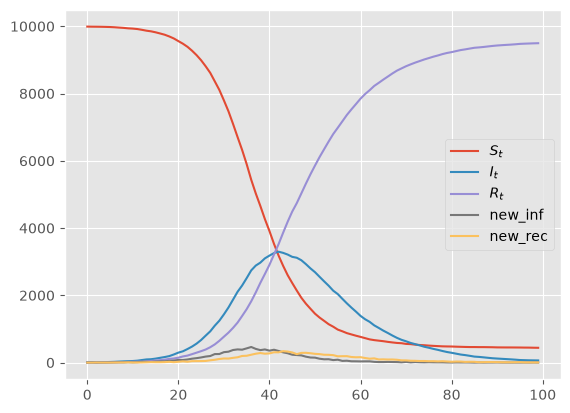

In [3]:
# Plot count of new infections, new recoveries, susceptibles, infectious, and removed
plt.style.use('ggplot')
plt.plot([xt['S'] for xt in x], label=r'$S_t$')
plt.plot([xt['I'] for xt in x], label=r'$I_t$')
plt.plot([xt['R'] for xt in x], label=r'$R_t$')
plt.plot([xt['new_inf'] for xt in x], label='new_inf')
plt.plot([xt['new_rec'] for xt in x], label='new_rec')
plt.legend()

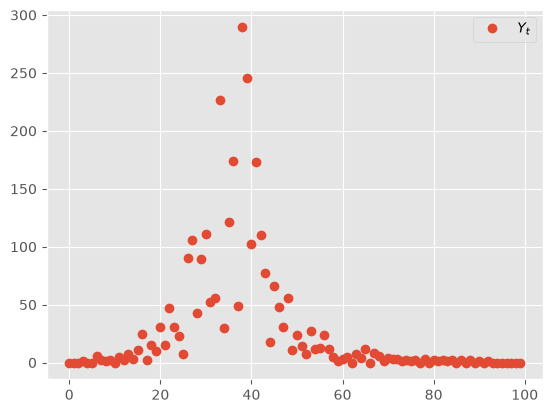

In [4]:
# Plot the observation model
plt.style.use('ggplot')
plt.plot(y, label=r'$Y_t$', linestyle='', marker='o')

plt.legend()

# DataFrames & csv files

In [5]:
simulation_df = pd.DataFrame(np.concatenate(x))
print(simulation_df)

    new_inf  new_rec       S     I       R
0       0.0      0.0  9990.0  10.0     0.0
1       3.0      0.0  9987.0  13.0     0.0
2       1.0      3.0  9986.0  11.0     3.0
3       2.0      1.0  9984.0  12.0     4.0
4       3.0      1.0  9981.0  14.0     5.0
..      ...      ...     ...   ...     ...
95      1.0     12.0   448.0  76.0  9476.0
96      2.0      6.0   446.0  72.0  9482.0
97      1.0      5.0   445.0  68.0  9487.0
98      3.0      5.0   442.0  66.0  9492.0
99      2.0      4.0   440.0  64.0  9496.0

[100 rows x 5 columns]


In [6]:
observation_df = pd.DataFrame(np.concatenate(y))
observation_df = observation_df.rename(columns={0: 'observations'})
print(observation_df)

    observations
0              0
1              0
2              0
3              1
4              0
..           ...
95             0
96             0
97             0
98             0
99             0

[100 rows x 1 columns]


In [7]:
# Save to csv - commented out until needed

"""simulation_df.to_csv('sir_simulation.csv', index=False)
observation_df.to_csv('sir_observation.csv', index=False)"""

"simulation_df.to_csv('sir_simulation.csv', index=False)\nobservation_df.to_csv('sir_observation.csv', index=False)"

# Sequential Monte Carlo

In [8]:
fk = ssm.Bootstrap(ssm=model, data=y)
alg = particles.SMC(fk=fk, 
                    N=5000,
                    resampling = 'systematic', 
                    verbose=True,
                    collect=[Moments(mom_func = custom_mom)])
alg.run()

t=0: resample:False, ESS (end of iter)=5000.00
t=1: resample:False, ESS (end of iter)=4582.69
t=2: resample:False, ESS (end of iter)=3970.14
t=3: resample:False, ESS (end of iter)=3876.36
t=4: resample:False, ESS (end of iter)=3044.47
t=5: resample:False, ESS (end of iter)=2134.43
t=6: resample:True, ESS (end of iter)=2485.38
t=7: resample:True, ESS (end of iter)=4887.63
t=8: resample:False, ESS (end of iter)=4615.82
t=9: resample:False, ESS (end of iter)=4409.49
t=10: resample:False, ESS (end of iter)=3096.47
t=11: resample:False, ESS (end of iter)=3314.23
t=12: resample:False, ESS (end of iter)=2826.10
t=13: resample:False, ESS (end of iter)=2987.50
t=14: resample:False, ESS (end of iter)=2568.87
t=15: resample:False, ESS (end of iter)=2728.96
t=16: resample:False, ESS (end of iter)=2702.85
t=17: resample:False, ESS (end of iter)=2359.25
t=18: resample:True, ESS (end of iter)=4957.24
t=19: resample:False, ESS (end of iter)=4878.68
t=20: resample:False, ESS (end of iter)=4733.94
t=21:

# Moments

In [9]:
# Create a list of 'I' means 
I_means = []
for a in range(100):
    I = alg.summaries.moments[a]['mean'][3]
    I_means.append(I)

print(I_means)
print(len(I_means))

[10.000000000000007, 11.536641379099796, 13.15018552583817, 16.05426858085713, 17.779081641711024, 19.37860615494106, 29.61286823946729, 35.78667687441991, 40.64995142101075, 47.73119101239238, 50.56763964339077, 63.84971535198032, 72.24955540454576, 90.53116262954018, 102.68616280723569, 129.67802837204854, 176.66796298512102, 196.79543959736927, 236.67709824162026, 274.14806021570274, 340.5417528514493, 395.25753726641534, 488.1760224266465, 574.9230115931887, 663.0604473402552, 746.6254912323193, 903.0116457284036, 1079.3262700984806, 1228.7970087703163, 1412.5738552297307, 1613.705629918326, 1799.5446082640738, 1991.234759660601, 2219.392423611369, 2404.642432560309, 2588.583274086911, 2755.0790196645466, 2898.3912424590903, 3007.3087475723323, 3090.3914360691506, 3152.047192599622, 3182.34086719884, 3187.670511319597, 3167.439767890526, 3114.6661638413075, 3046.9337045427064, 2959.246391125123, 2852.02518522352, 2746.6880854882797, 2612.6820592867757, 2482.7820505798713, 2344.9734

Text(0, 0.5, 'Mean "I"')

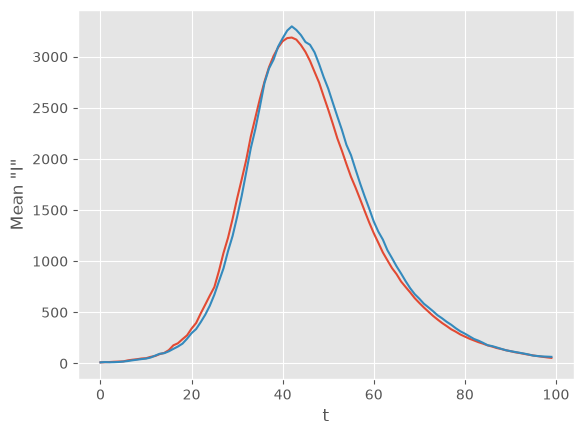

In [10]:
plt.plot(I_means)
plt.plot([xt['I'] for xt in x], label=r'$I_t$')
plt.xlabel('t')
plt.ylabel('Mean "I"')

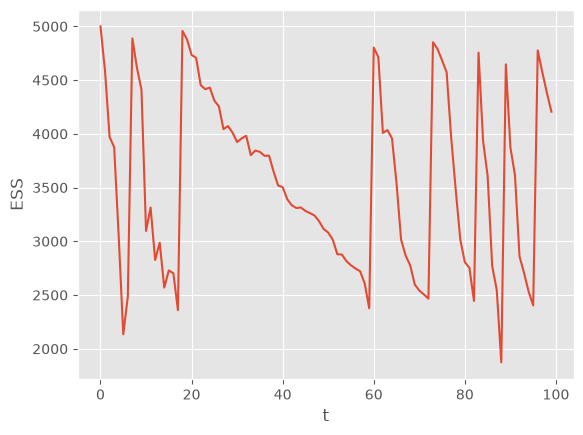

In [11]:
plt.plot(alg.summaries.ESSs)
plt.xlabel('t')
plt.ylabel('ESS');

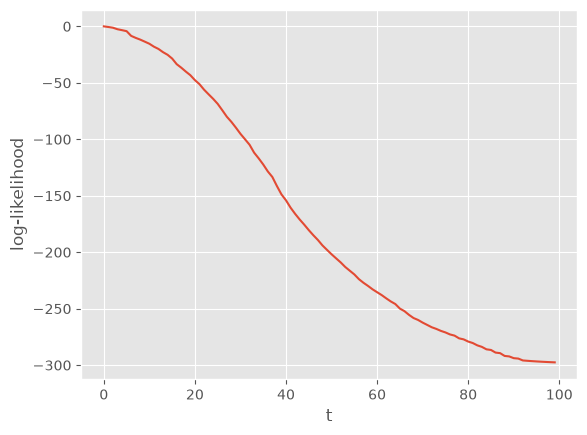

In [12]:
plt.plot(alg.summaries.logLts)
plt.xlabel('t')
plt.ylabel('log-likelihood');

# Priors

In [13]:
prior_dict = {'beta': dists.Uniform(a=0, b=0.5),
              'gamma': dists.Uniform(a= 0, b= 0.5)}  # Uniform distribution because the prior is uninformative

my_prior = ScalarStructDist(prior_dict)      # need this because 'dict' object has no attribute 'dtype' but StructDist does

# PMMH

In [14]:
path = "/Users/gabriellebouvier/SIR_Model/pmmh_chain.pkl"
with open(path, 'rb') as output:
    chain = pickle.load(output)

print(chain.theta['beta'])

[0.06204881 0.06204881 0.06204881 ... 0.32583594 0.32583594 0.28584124]


In [159]:
print(chain.lpost)

[-1188.9419057  -1188.9419057  -1188.9419057  ...  -301.92558404
  -301.92558404  -300.556619  ]


Time taken: 1075.78 seconds

/var/folders/78/7v9nz15x7059dykx93846qzm0000gn/T/ipykernel_94133/75745475.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(chain.theta[param][burnin:])
/var/folders/78/7v9nz15x7059dykx93846qzm0000gn/T/ipykernel_94133/75745475.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(chain.theta[param

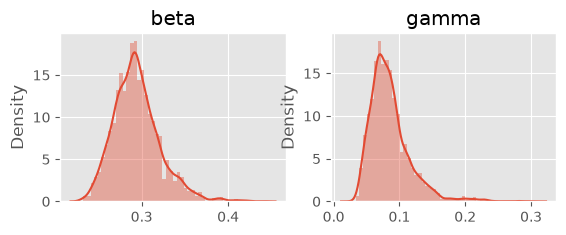

In [15]:
# plot the marginals
burnin = 100
for i, param in enumerate(prior_dict.keys()):
    plt.subplot(2, 2, i+1)
    sb.distplot(chain.theta[param][burnin:])
    plt.title(param)

In [16]:
samples = np.asarray(chain.theta[param][burnin:])
print("NaN:", np.isnan(samples).sum())
print("Inf:", np.isinf(samples).sum())
print("Min:", np.nanmin(samples))
print("Max:", np.nanmax(samples))

NaN: 0
Inf: 0
Min: 0.028160771481772116
Max: 0.30590617079311816


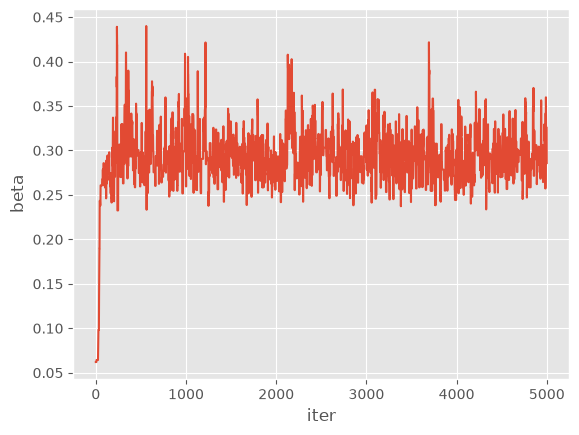

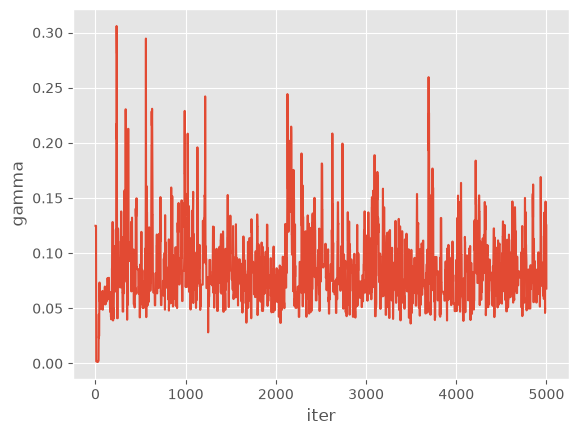

In [17]:
for p in prior_dict.keys():  
    plt.figure()
    plt.plot(chain.theta[p])
    plt.xlabel('iter')
    plt.ylabel(p)

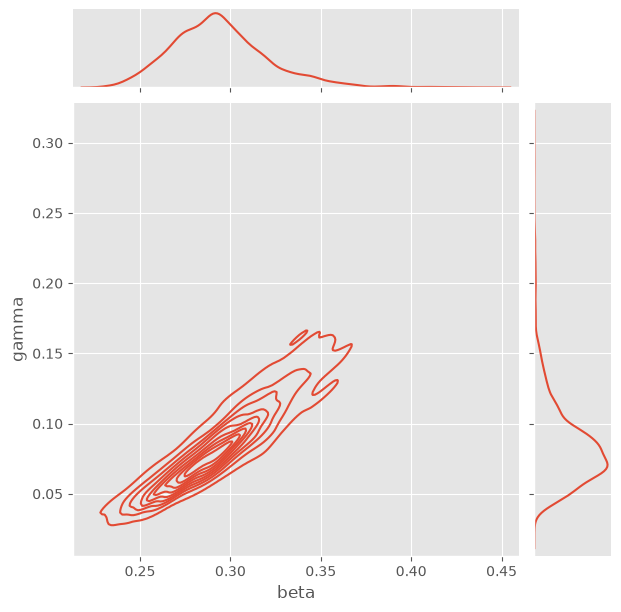

In [18]:
beta_density = chain.theta['beta'][burnin:]
gamma_density = chain.theta['gamma'][burnin:]
sb.jointplot(x = beta_density, y = gamma_density, kind = 'kde')
plt.xlabel('beta')
plt.ylabel('gamma')
plt.show()

# Multiprocess: Multiple Chains

In [ ]:
path_multi = '/Users/gabriellebouvier/SIR_Model/pmmh_chain_multi.pkl'
with open(path_multi, 'rb') as output_multi:
    chain_multi = pickle.load(output_multi)

print(type(chain_multi[0]))
print(chain_multi[0][0]['theta'])

print(chain_multi[1][0])
print(chain_multi[2][0])
print(chain_multi[3][0])


<class 'particles.smc_samplers.ThetaParticles'>
(0.208511, 0.36016225)
(0.31185383418419177, 0.12650813179046605)
{'theta': (0.21799745, 0.01296312), 'lpost': -317.5292188192771}
{'theta': (0.27539895, 0.35407391), 'lpost': -480.64595274420134}
{'theta': (0.48351492, 0.27361612), 'lpost': -318.6859240396933}


In [137]:
beta_chain_0 = [p['theta']['beta'] for p in chain_multi[0]]
gamma_chain_0 = [p['theta']['gamma'] for p in chain_multi[0]]

beta_chain_1 = [p['theta']['beta'] for p in chain_multi[1]]
gamma_chain_1 = [p['theta']['gamma'] for p in chain_multi[1]]

beta_chain_2 = [p['theta']['beta'] for p in chain_multi[2]]
gamma_chain_2 = [p['theta']['gamma'] for p in chain_multi[2]]

beta_chain_3 = [p['theta']['beta'] for p in chain_multi[3]]
gamma_chain_3 = [p['theta']['gamma'] for p in chain_multi[3]]

print(gamma_chain_3)

[0.27361612458786116, 0.27361612458786116, 0.27361612458786116, 0.27361612458786116, 0.27361612458786116, 0.27361612458786116, 0.27361612458786116, 0.27361612458786116, 0.27361612458786116, 0.27361612458786116, 0.27361612458786116, 0.27361612458786116, 0.27361612458786116, 0.25033679823193716, 0.25033679823193716, 0.25033679823193716, 0.25033679823193716, 0.25940073240256084, 0.25940073240256084, 0.25940073240256084, 0.25940073240256084, 0.18917442922498473, 0.18917442922498473, 0.18917442922498473, 0.18917442922498473, 0.18917442922498473, 0.18917442922498473, 0.18917442922498473, 0.18917442922498473, 0.18917442922498473, 0.18917442922498473, 0.18917442922498473, 0.12813577755597153, 0.12813577755597153, 0.11084555450778347, 0.15020475796490207, 0.15020475796490207, 0.15020475796490207, 0.08883809712969938, 0.08627310403141952, 0.08627310403141952, 0.08627310403141952, 0.08627310403141952, 0.08627310403141952, 0.08627310403141952, 0.08627310403141952, 0.08627310403141952, 0.0862731040

Time taken: 1201.39 seconds

## Plot Marginals

/var/folders/78/7v9nz15x7059dykx93846qzm0000gn/T/ipykernel_94133/1734036830.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(beta_chain_0[burnin:], ax=axes[0,0]).set(title='Beta Chain 0')
/var/folders/78/7v9nz15x7059dykx93846qzm0000gn/T/ipykernel_94133/1734036830.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bb

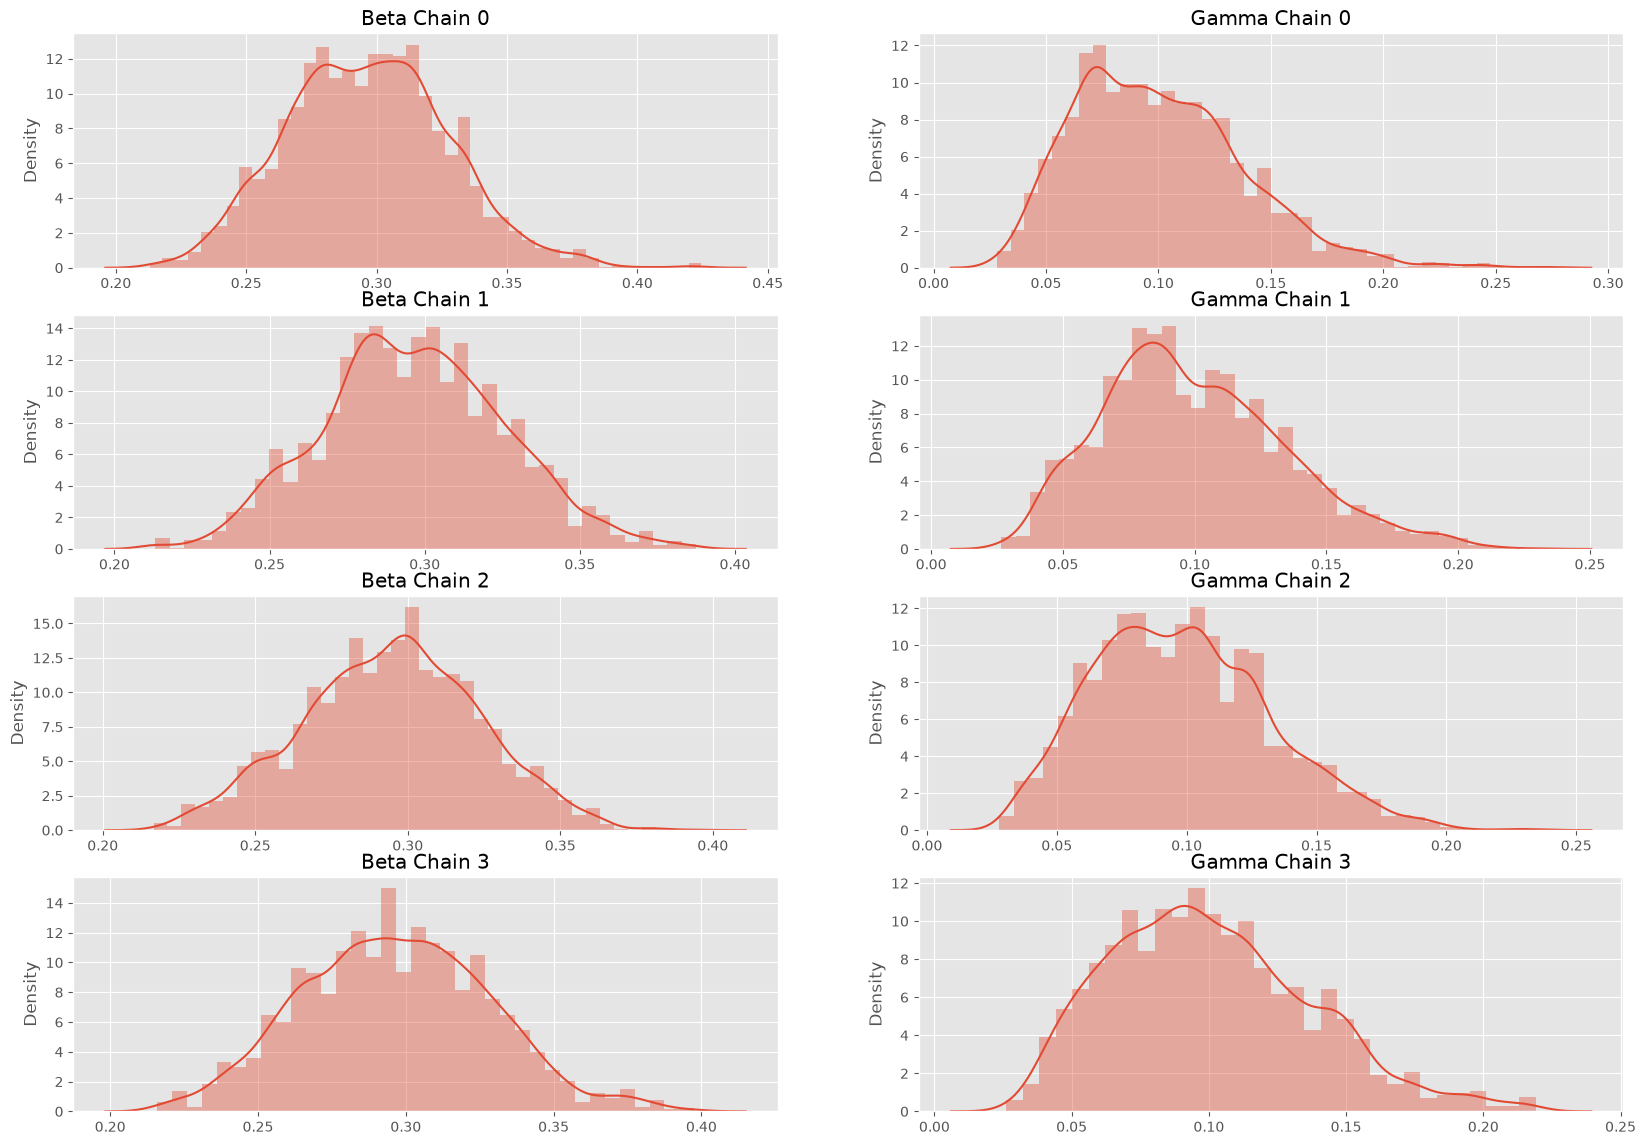

In [143]:
burnin = 100
fig, axes = plt.subplots(4,2)
sb.distplot(beta_chain_0[burnin:], ax=axes[0,0]).set(title='Beta Chain 0')
sb.distplot(gamma_chain_0[burnin:], ax=axes[0,1]).set(title='Gamma Chain 0')
sb.distplot(beta_chain_1[burnin:], ax=axes[1,0]).set(title='Beta Chain 1')
sb.distplot(gamma_chain_1[burnin:], ax=axes[1,1]).set(title='Gamma Chain 1')
sb.distplot(beta_chain_2[burnin:], ax=axes[2,0]).set(title='Beta Chain 2')
sb.distplot(gamma_chain_2[burnin:], ax=axes[2,1]).set(title='Gamma Chain 2')
sb.distplot(beta_chain_3[burnin:], ax=axes[3,0]).set(title='Beta Chain 3')
sb.distplot(gamma_chain_3[burnin:], ax=axes[3,1]).set(title='Gamma Chain 3')
fig.set_figheight(14)
fig.set_figwidth(20)

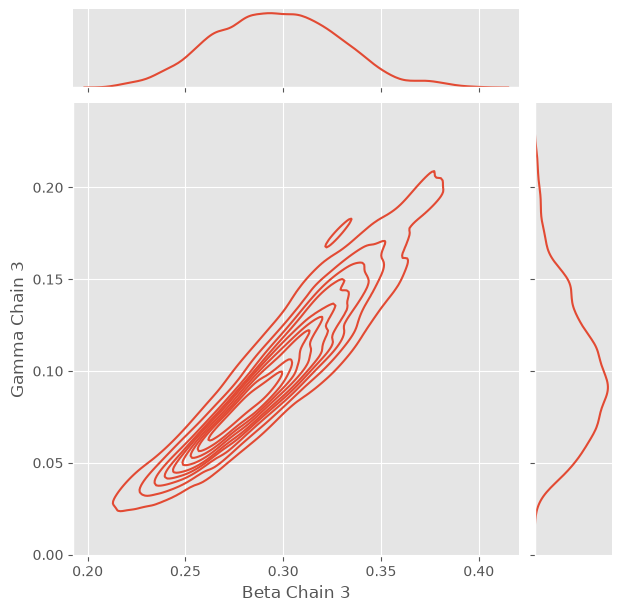

In [168]:
beta_density_3 = beta_chain_3[burnin:]
gamma_density_3 = gamma_chain_3[burnin:]
sb.jointplot(x = beta_density_3, y = gamma_density_3, kind = 'kde')
plt.xlabel('Beta Chain 3')
plt.ylabel('Gamma Chain 3')
plt.show()

## Trace Plot

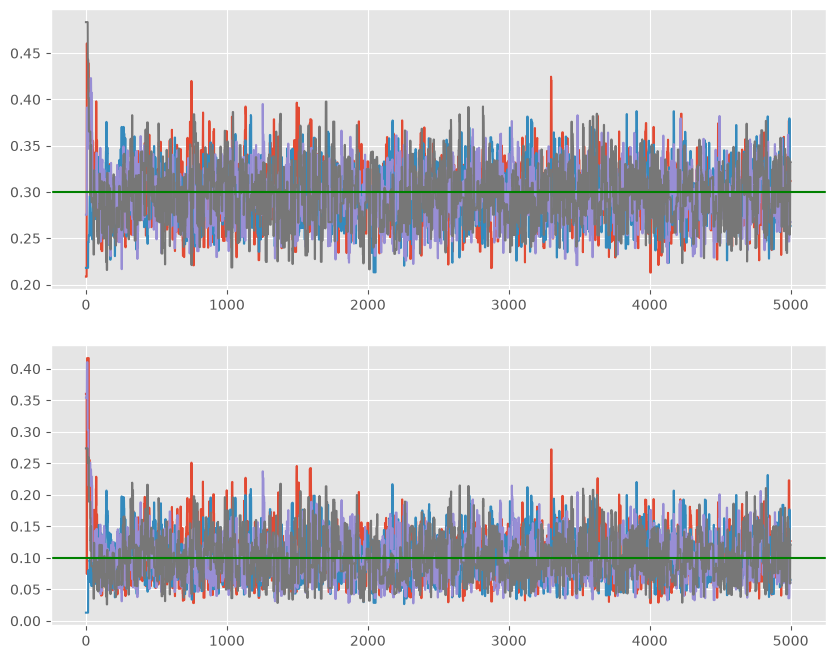

In [157]:
fig, axes = plt.subplots(2,1)
axes[0].plot(beta_chain_0)
axes[0].plot(beta_chain_1)
axes[0].plot(beta_chain_2)
axes[0].plot(beta_chain_3)
axes[1].plot(gamma_chain_0)
axes[1].plot(gamma_chain_1)
axes[1].plot(gamma_chain_2)
axes[1].plot(gamma_chain_3)
fig.set_figheight(8)
fig.set_figwidth(10)
axes[0].axhline(y = 0.3, color='green')
axes[1].axhline(y = 0.1, color='green')

## Posterior Means

In [177]:
beta_chain_0_mean = statistics.mean(beta_chain_0[burnin:])
gamma_chain_0_mean = statistics.mean(gamma_chain_0[burnin:])
beta_chain_1_mean = statistics.mean(beta_chain_1[burnin:])
gamma_chain_1_mean = statistics.mean(gamma_chain_1[burnin:])
beta_chain_2_mean = statistics.mean(beta_chain_2[burnin:])
gamma_chain_2_mean = statistics.mean(gamma_chain_2[burnin:])
beta_chain_3_mean = statistics.mean(beta_chain_3[burnin:])
gamma_chain_3_mean = statistics.mean(gamma_chain_3[burnin:])

print(beta_chain_0_mean)
print(beta_chain_1_mean)
print(beta_chain_2_mean)
print(beta_chain_3_mean)
print(gamma_chain_0_mean)
print(gamma_chain_1_mean)
print(gamma_chain_2_mean)
print(gamma_chain_3_mean)


0.29661640571344033
0.2965395111076523
0.29470293619442256
0.2966955542366031
0.10014507371255148
0.09980009921764481
0.09817276594613102
0.10058731106513036
